# Bloque IV — Parte 2 (Entrega Completa y Final)

Clustering con K-Means y DBSCAN, evaluación con silhouette, PCA y conclusiones de negocio.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%matplotlib inline

In [2]:
DATA_DIR = Path(".")
df = pd.read_csv(DATA_DIR / "clientes_clustering.csv")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

df.head()

,frecuencia,importe_medio,recencia,interacciones
0,2.486233,3.406470,-9.480073,9.203600
1,-6.528387,-7.658484,-9.098481,6.707272
2,-3.108165,8.782212,3.256960,0.477911
3,-3.475229,8.718263,4.033174,2.075512
4,1.939700,2.647681,-10.403105,9.457445


## Evaluación de K-Means con silhouette

In [3]:
scores = []

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append({"k": k, "silhouette": score})

scores_df = pd.DataFrame(scores)
scores_df

,k,silhouette
0,2,0.486385
1,3,0.681185
2,4,0.793038
3,5,0.654425
4,6,0.498235
5,7,0.362673


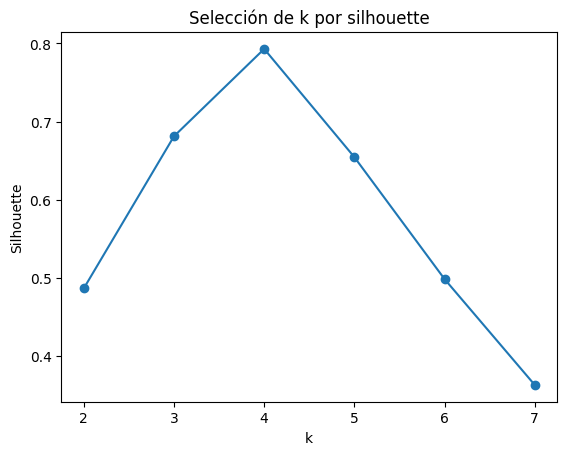

In [4]:
plt.figure()
plt.plot(scores_df["k"], scores_df["silhouette"], marker="o")
plt.title("Selección de k por silhouette")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

## Selección del mejor modelo K-Means

In [5]:
k_final = int(scores_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
k_final

4

In [6]:
km = KMeans(n_clusters=k_final, random_state=42, n_init=10)

df_clustered = df.copy()
df_clustered["cluster"] = km.fit_predict(X_scaled)

df_clustered["cluster"].value_counts()

cluster
1    60
3    60
2    60
0    60
Name: count, dtype: int64

## Perfilado de clusters

In [7]:
perfil = df_clustered.groupby("cluster").mean().round(2)
perfil

,frecuencia,importe_medio,recencia,interacciones
cluster,,,,
0,6.78,-5.65,-6.16,-6.01
1,1.76,4.11,-9.63,9.41
2,-2.63,9.08,4.49,2.08
3,-6.74,-6.85,-8.72,7.18


## PCA para visualización

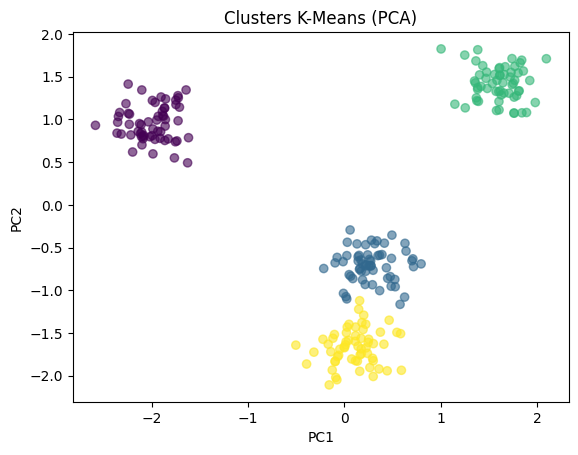

In [8]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(coords[:,0], coords[:,1], c=df_clustered["cluster"], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters K-Means (PCA)")
plt.show()

## DBSCAN (modelo alternativo)

In [9]:
db = DBSCAN(eps=0.8, min_samples=5)
labels_db = db.fit_predict(X_scaled)

df_clustered["cluster_db"] = labels_db

df_clustered["cluster_db"].value_counts()

cluster_db
0    60
1    60
2    60
3    60
Name: count, dtype: int64

## Conclusiones


- K-Means permite segmentar claramente a los clientes en grupos diferenciados.
- El número óptimo de clusters se ha determinado mediante silhouette, garantizando buena separación.
- PCA confirma visualmente la estructura de los clusters.
- DBSCAN detecta posibles outliers, aportando valor adicional al análisis.

### Interpretación de negocio
- Clientes con altos valores → segmento premium (fidelización).
- Clientes con alta actividad pero bajo gasto → potencial de conversión.
- Clientes inactivos → campañas de reactivación.
- Outliers detectados → análisis individual.

### Conclusión final
La combinación de K-Means y DBSCAN permite una segmentación robusta, útil para estrategias comerciales basadas en comportamiento real del cliente.
